<a href="https://colab.research.google.com/github/Alimusy/OIBSIP/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [9]:
# Load the dataset
df = pd.read_csv('Advertising.csv')

print("Initial Data Head:")
print("-" * 50)
display(df.head())
print("-" * 50)

Initial Data Head:
--------------------------------------------------


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


--------------------------------------------------


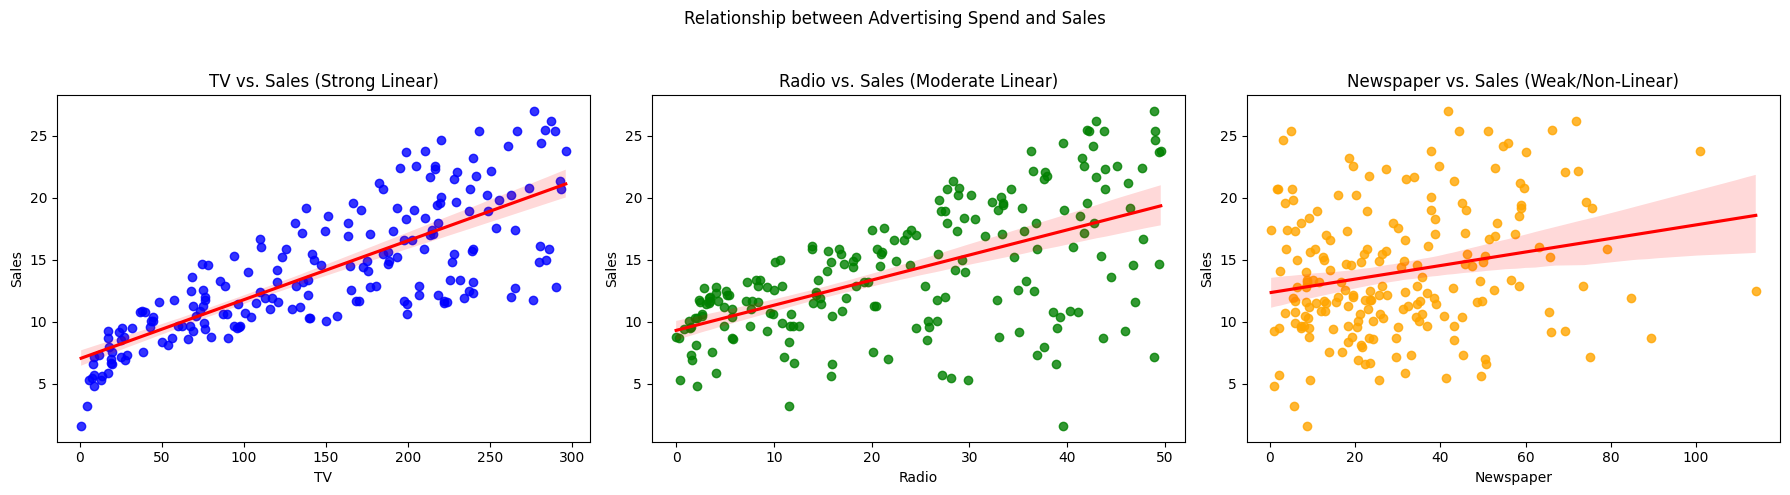

In [4]:
# Create a figure with three subplots for each feature vs. Sales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relationship between Advertising Spend and Sales')

# TV vs. Sales
sns.regplot(x='TV', y='Sales', data=df, ax=axes[0], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
axes[0].set_title('TV vs. Sales (Strong Linear)')

# Radio vs. Sales
sns.regplot(x='Radio', y='Sales', data=df, ax=axes[1], scatter_kws={'color': 'green'}, line_kws={'color': 'red'})
axes[1].set_title('Radio vs. Sales (Moderate Linear)')

# Newspaper vs. Sales
sns.regplot(x='Newspaper', y='Sales', data=df, ax=axes[2], scatter_kws={'color': 'orange'}, line_kws={'color': 'red'})
axes[2].set_title('Newspaper vs. Sales (Weak/Non-Linear)')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [12]:
# Define X and Y
X = df[['TV', 'Radio', 'Newspaper']]
Y = df['Sales']

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, Y_train)

# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate Metrics
mae = mean_absolute_error(Y_test, predictions)
r2 = r2_score(Y_test, predictions)

print("\n--- Model Training & Results ---")
print(f"Intercept (Baseline Sales): {model.intercept_:.4f}")
print("Coefficients (Impact per $1 spent):")
for feature, coef in zip(X.columns, model.coef_):
    display(f"  {feature}: {coef:.4f}")

print("\n--- Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R-squared Score (R2): {r2:.4f}")


--- Model Training & Results ---
Intercept (Baseline Sales): 2.7089
Coefficients (Impact per $1 spent):


'  TV: 0.0441'

'  Radio: 0.1993'

'  Newspaper: 0.0069'


--- Evaluation Metrics ---
Mean Absolute Error (MAE): 1.512
R-squared Score (R2): 0.8609


In [11]:
# Get user input for a new quarter's budget (in thousands)
tv_budget = float(input("Enter the TV advertising budget (in thousands): "))
radio_budget = float(input("Enter the Radio advertising budget (in thousands): "))
newspaper_budget = float(input("Enter the Newspaper advertising budget (in thousands): "))

new_budget = pd.DataFrame({
    'TV': [tv_budget],
    'Radio': [radio_budget],
    'Newspaper': [newspaper_budget]
})

predicted_sales = model.predict(new_budget)[0]
print(f"\nPredicted Sales for the new budget: {predicted_sales:.2f} (in thousands of units)")

Enter the TV advertising budget (in thousands): 50
Enter the Radio advertising budget (in thousands): 20
Enter the Newspaper advertising budget (in thousands): 10

Predicted Sales for the new budget: 8.97 (in thousands of units)
